In [1]:
import json
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [2]:
!wget --no-check-certificate \
    https://storage.googleapis.com/learning-datasets/sarcasm.json \
    -O /tmp/sarcasm.json # dataset


--2026-10-03 16:13:26--  https://storage.googleapis.com/learning-datasets/sarcasm.json
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.12.207, 172.217.194.207, 74.125.24.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.12.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5643545 (5.4M) [application/json]
Saving to: ‘/tmp/sarcasm.json’

/tmp/sarcasm.json   100%[===================>]   5.38M  3.86MB/s    in 1.4s    

2026-10-03 16:13:29 (3.86 MB/s) - ‘/tmp/sarcasm.json’ saved [5643545/5643545]



In [3]:
with open("/tmp/sarcasm.json", 'r') as f: # abrindo o arquivo
    datastore = json.load(f) # carregando os dados

sentences = [] # lista de sentenças
labels = [] # lista de labels
urls = [] # lista de urls

for item in datastore:
    # carrega os valores para cada lista
    sentences.append(item['headline'])
    labels.append(item['is_sarcastic'])
    urls.append(item['article_link'])

In [4]:
vocab_size = 10000       # tamanho máximo do vocabulário
embedding_dim = 16       # dimensão dos embeddings
max_length = 100         # tamanho máximo das sequências
trunc_type = 'post'      # corta palavras no final
padding_type = 'post'    # adiciona preenchimento no final
oov_tok = "<OOV>"        # token para palavras desconhecidas
training_size = 20000    # quantidade de dados para treino

In [5]:
training_sentences = sentences[0:training_size]  # sentenças para treino
testing_sentences = sentences[training_size:]    # sentenças para teste

training_labels = labels[0:training_size]        # labels para treino
testing_labels = labels[training_size:]          # labels para teste

In [6]:
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)  # cria o tokenizador
tokenizer.fit_on_texts(training_sentences)  # aprende o vocabulário

word_index = tokenizer.word_index  # armazena o índice das palavras

training_sequences = tokenizer.texts_to_sequences(training_sentences)  # transforma treino em sequências numéricas
training_padded = pad_sequences(training_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)  # padroniza o tamanho do treino

testing_sequences = tokenizer.texts_to_sequences(testing_sentences)  # transforma teste em sequências numéricas
testing_padded = pad_sequences(testing_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)  # padroniza o tamanho do teste

In [7]:
import numpy as np

# converte dados e labels para array
training_padded = np.array(training_padded)
training_labels = np.array(training_labels)

testing_padded = np.array(testing_padded)
testing_labels = np.array(testing_labels)

In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, 64),  # Representa as palavras em vetores
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),  # Mantém a sequência para a próxima LSTM
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),  # LSTM analisa a sequência nos dois sentidos
    tf.keras.layers.Dense(64, activation='relu'),  # Camada oculta com ReLU
    tf.keras.layers.Dense(1, activation='sigmoid')  # Saída binária
])

model.compile(
    loss='binary_crossentropy',  # Função de perda para classificação binária
    optimizer='adam',  # Otimizador
    metrics=['accuracy']  # Métrica de acurácia
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
num_epochs = 30 # numero de epocas
history = model.fit(training_padded, training_labels, epochs=num_epochs, validation_data=(testing_padded, testing_labels), verbose=2)

Epoch 1/30
625/625 - 65s - 104ms/step - accuracy: 0.8120 - loss: 0.3875 - val_accuracy: 0.8225 - val_loss: 0.3771
Epoch 2/30
625/625 - 61s - 97ms/step - accuracy: 0.9222 - loss: 0.1946 - val_accuracy: 0.8527 - val_loss: 0.3794
Epoch 3/30
625/625 - 87s - 139ms/step - accuracy: 0.9629 - loss: 0.1060 - val_accuracy: 0.8468 - val_loss: 0.4186
Epoch 4/30
625/625 - 76s - 122ms/step - accuracy: 0.9778 - loss: 0.0633 - val_accuracy: 0.8419 - val_loss: 0.5533
Epoch 5/30
625/625 - 60s - 96ms/step - accuracy: 0.9879 - loss: 0.0379 - val_accuracy: 0.8350 - val_loss: 0.6160
Epoch 6/30
625/625 - 61s - 98ms/step - accuracy: 0.9919 - loss: 0.0245 - val_accuracy: 0.8362 - val_loss: 0.7459
Epoch 7/30
625/625 - 89s - 143ms/step - accuracy: 0.9942 - loss: 0.0188 - val_accuracy: 0.8372 - val_loss: 0.8058
Epoch 8/30
625/625 - 61s - 98ms/step - accuracy: 0.9949 - loss: 0.0154 - val_accuracy: 0.8323 - val_loss: 0.9592
Epoch 9/30
625/625 - 65s - 104ms/step - accuracy: 0.9952 - loss: 0.0136 - val_accuracy: 0.83

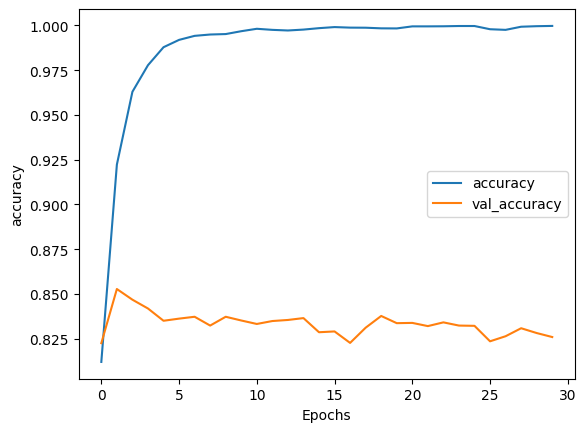

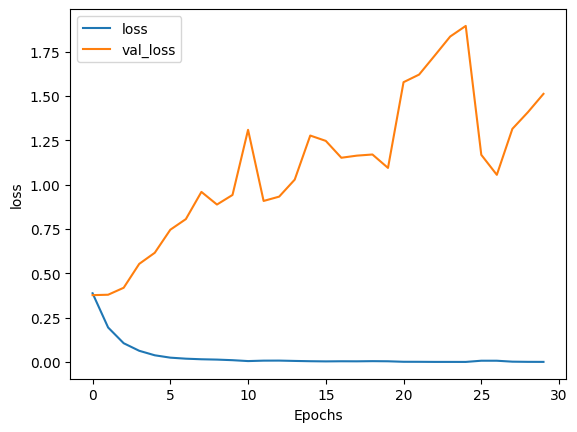

In [13]:
import matplotlib.pyplot as plt


def plot_graphs(history, string): # cria um grafico de acuracia e val_acuracia/loss e val_loss
  plt.plot(history.history[string])
  plt.plot(history.history['val_'+string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()

plot_graphs(history, "accuracy")
plot_graphs(history, "loss")

In [14]:
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()]) # inverte o índice das palavras

def decode_sentence(text): # converte números de volta para palavras
    return ' '.join([reverse_word_index.get(i, '?') for i in text])

print(decode_sentence(training_padded[0])) # mostra a sentença decodificada
print(training_sentences[2]) # mostra a sentença original
print(labels[2]) # mostra o label da sentença

former <OOV> store clerk sues over secret 'black <OOV> for minority shoppers ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ?
mom starting to fear son's web series closest thing she will have to grandchild
1


In [15]:
e = model.layers[0]
weights = e.get_weights()[0]
print(weights.shape) # mostra o formato

(10000, 64)


In [16]:
import io

out_v = io.open('vecs.tsv', 'w', encoding='utf-8') # arquivo dos vetores
out_m = io.open('meta.tsv', 'w', encoding='utf-8') # arquivo das palavras
for word_num in range(1, vocab_size):
  word = reverse_word_index[word_num] # recupera a palavra pelo índice
  embeddings = weights[word_num] # recupera o vetor da palavra
  out_m.write(word + "\n") # salva a palavra
  out_v.write('\t'.join([str(x) for x in embeddings]) + "\n") # salva o vetor
# fecha os arquivos
out_v.close()
out_m.close()

In [17]:
try:
  from google.colab import files
except ImportError: # ignora caso não esteja executando no Colab
  pass
else: # baixa o arquivo
  files.download('vecs.tsv')
  files.download('meta.tsv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
sentence = ["granny starting to fear spiders in the garden might be real", "game of thrones season finale showing this sunday night"] # frases para teste
sequences = tokenizer.texts_to_sequences(sentence) # converte as frases em sequências numéricas

padded = pad_sequences(sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type) # padroniza o tamanho das sequências
print(model.predict(padded)) # realiza previsão do modelo

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step
[[0.00264203]
 [0.00012281]]
